# Analaysis of deep learning models segmentation performance for rescaled images
This notebook allows to compare the results obtained for segmentation and the ground truth across image resolutions. The notebook will compute the following metrics and provide plots to visualise the results: 
- Mean Intersection-over-Union (IoU) as described in the Cell Tracking Challenge (True positives identified with a minimum of 50% overlap).
- Object diameter
- Theoretical throughput

**Expected output**:
- A new folder (`Results`) in the main directory with `.csv`files containing the numerical data for the assessment.
- Images of true positives, false positives, and false negatives for each image.



## 1. Import dependencies

In [1]:
from rescale4dl import analyse
from rescale4dl.plot import custom_boxplot, plot_segmentation_example, plot_data_distributions
from rescale4dl import stats
import shutil
import os
import pandas as pd
from rescale4dl.utils import get_csv_dict
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Compile quantitative data
This cell will compute analytical measurements for all the datasets and rescaling factors contained in the given INPUT_DIR.
-  **INPUT_DIR**  
   - Path to the folder containing the input images and the annotations, stored as `.tiff`files.
   - The input directory is expected to have the following structure (preserving the naming for "GT" and "Prediction" folders)
        - **DATASET (e.g., Saureus_instance_segmentation)**
            * **OG**
                * GT
                    - images.tiff
                * Prediction
                    - images.tiff
            * **downsampling_2**
                * GT
                    - images.tiff
                * Prediction
                    - images.tiff
 
   - Example: `/path/to/your/input`

In [ ]:
# Directory with folders of sampling folders with GT and Prediction folder pairs inside
INPUT_DIR = "/Volumes/MGF_Backups/workingenv/NUCLEI"

# List of sampling folders to be included in the analysis. If None, all folders in the datasets of the input directory will be included.
# sampling_dir_list = [
#         "upsampling_16",
#         "upsampling_8",
#         "upsampling_4",
#         "upsampling_2",
#         "OG",
#         "downsampling_2",
#         "downsampling_4",
#         "downsampling_8",
#         "downsampling_16",
#     ]
# Calculate object properties statistics
analyse(INPUT_DIR, sampling_dir_list=None)

Calculating properties for nuclei_aiobio_20xdata_rescalemodels
Sampling folders to analyze: ['10x', '20x', '60x', '40x']
Reading file: /Volumes/MGF_Backups/workingenv/NUCLEI/nuclei_aiobio_20xdata_rescalemodels/10x/GT/20x_dapi60ms_tritc50ms_1-4mmFOV_007_3.tif
20x_dapi60ms_tritc50ms_1-4mmFOV_007_3.tif from 10x has 66 objects in GT and 71 objects in Prediction
Elapsed time: 00:00:01
Reading file: /Volumes/MGF_Backups/workingenv/NUCLEI/nuclei_aiobio_20xdata_rescalemodels/10x/GT/20x_dapi60ms_tritc50ms_1-4mmFOV_004_2.tif
20x_dapi60ms_tritc50ms_1-4mmFOV_004_2.tif from 10x has 131 objects in GT and 130 objects in Prediction
Elapsed time: 00:00:01
Reading file: /Volumes/MGF_Backups/workingenv/NUCLEI/nuclei_aiobio_20xdata_rescalemodels/10x/GT/20x_dapi60ms_tritc50ms_1-4mmFOV_007_2.tif
20x_dapi60ms_tritc50ms_1-4mmFOV_007_2.tif from 10x has 93 objects in GT and 88 objects in Prediction
Elapsed time: 00:00:01
Reading file: /Volumes/MGF_Backups/workingenv/NUCLEI/nuclei_aiobio_20xdata_rescalemodels/10

### 2.1 Display some of the example results
Display an example ground truth labelling, the prediction and the difference between them. Expected input parameters:
1. **DATASET**  
   - Name of the dataset to display (e.g., `DATASET = "Saureus_instance_segmentation"`)
2. **SCALING**
   - Name of the folder corresponding to the scaling example to display (e.g., `SCALING = "downsampling_4"`)

In [ ]:
INPUT_DIR = "/Volumes/MGF_Backups/workingenv/NUCLEI"
DATASET = "nuclei_aiobio_grid1" 
SCALING = "60x" 

# Usage (same as before):
plot_segmentation_example(
    input_dir=INPUT_DIR,
    dataset=DATASET,
    scaling=SCALING,
    slice_axis=0,
)

## 3. Plot analytical results

### 3.1 Semantic segmentation
Example dataset: "Deepbacs_Semantic_Segmentation" (The example in this section expects section 2 to have been executed with the example data)


**Expected parameters**
1. **ANALYSIS_DIR**
   - Main directory where the DATASET folder stores all the csv files for morphology
2. **DATASET**
   - Name of the dataset, which also corresponds with its folder name, e.g., `DATASET = "Deepbacs_Semantic_Segmentation"`
3. **IMAGE_SIZES**
   - Path to the csv file containing basic information about the dataset. For the example data in the `segmentation_results` folder, the csv file can be found at `segmentation_results/DATASET/DATASET_dataset_info.csv`. For the paper results in the `analysis_results`, the csv file can be found at `analysis_results/dataset_info.csv`
4. **ORIGINAL_DATASET_FOLDERNAME**
   - The name of the folder in DATASET that corresponds to the original data. `"OG"` for the example data in `segmentation_results`; `"og"` for the example data in `"analysis_results"`.
5. **OUTPUT_DIR**
   - A directory to save the plots.
  
**Expected plots**
- IoU and Theoretical Throughput accross scales
- Barplot with diameter distributions for the ground truth and the segmentation results

DONE!
DONE!
DONE!


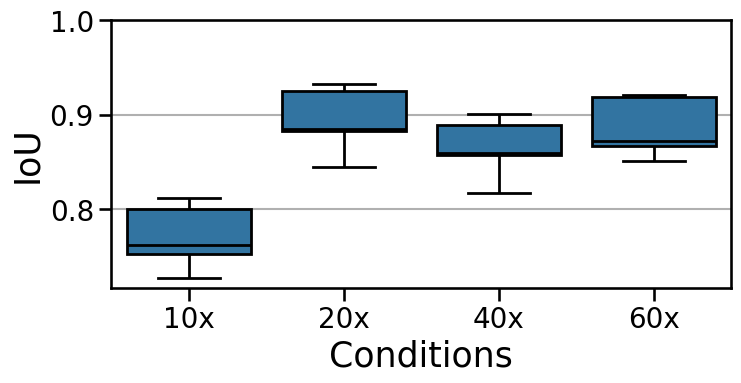

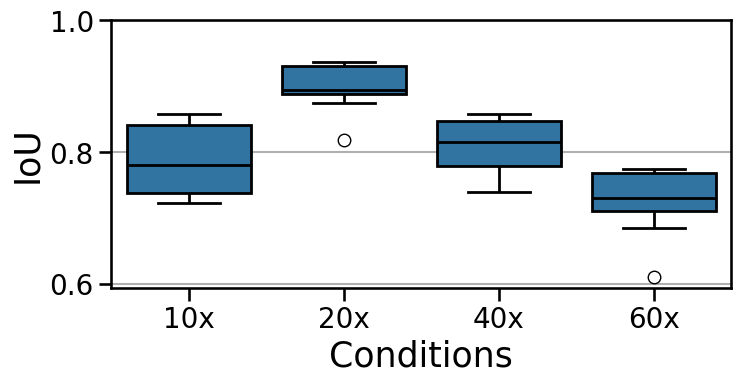

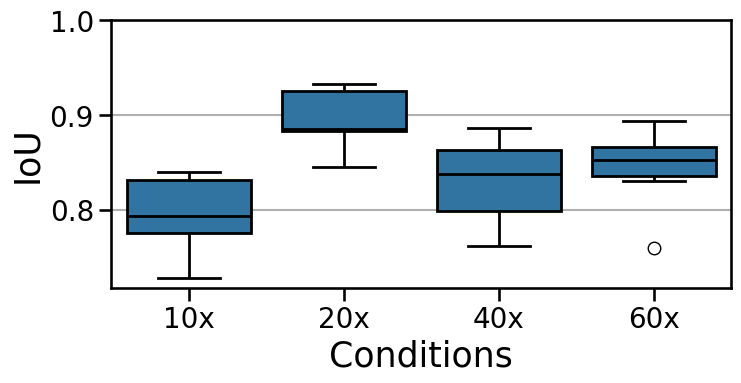

In [2]:
for DATASET in ["nuclei_aiobio_20xdata_rescalemodels", "nuclei_aiobio_grid1", "nuclei_aiobio_grid1_rescaled_data_20xmodel"]:
    ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/aiobio"
    OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET, "Results", "plots")

    ## Run
    dataset_name_match_dict = {DATASET: DATASET}
    fig_name = f"IoU for {DATASET}"
    y_axis = "IoU"
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    custom_boxplot(ANALYSIS_DIR,
                DATASET,
                fig_name, 
                y_axis,
                thoughput_plot=False, 
                x_axis_order = ["10x", "20x", "40x", "60x"],
                )



## 4. Statistical analysis
Calculate basic data distribution values and compare distributions accross different rescaling factors.
These can be calculated with the example data as follows:
1. **DATASET**
    - One of the following ones:
        - `"Saureus_instance_segmentation", "Deepbacs_Instance_Segmentation", "Deepbacs_Semantic_Segmentation", "Saureus_instance_segmentation_pc190723", "Saureus_instance_segmentation", "Worm_Semantic_Segmentation"`
2. **ANALYSIS_DIR**
    - The absolute path to `"Examples/analysis_results"`
3. **QUNATITATIVE_COLUMN**
    - Typically `"IoU"`. However, one can choose to compare other metrics such as `"f1_score", "pred_diameter_median", "pred_area", "Sensitivity", "pred_Circularity", "Accuracy"`. 
4. **CATEGORICAL_COLUMN**
    - List of column names dividing the data in groups for comparison. E.g., `["Grand_Parent_Folder"]`.
5. **TEST_TYPE**
    - `"t-test"`: When both groups are normally distributed and have equal variances.
    - `"Welch's t-test"`: When both groups are normally distributed and have unequal variances.
    - `"Kolmogorov-Smirnov"`: When at least one of the variables is not normally distributed. 
6. **TEST_CHOICE** 
  - `"Automatic"` if you want to run an automatic testing based on assessed properties of the data distribution. 
  - `"Manual"` to manually indicate what test to run.




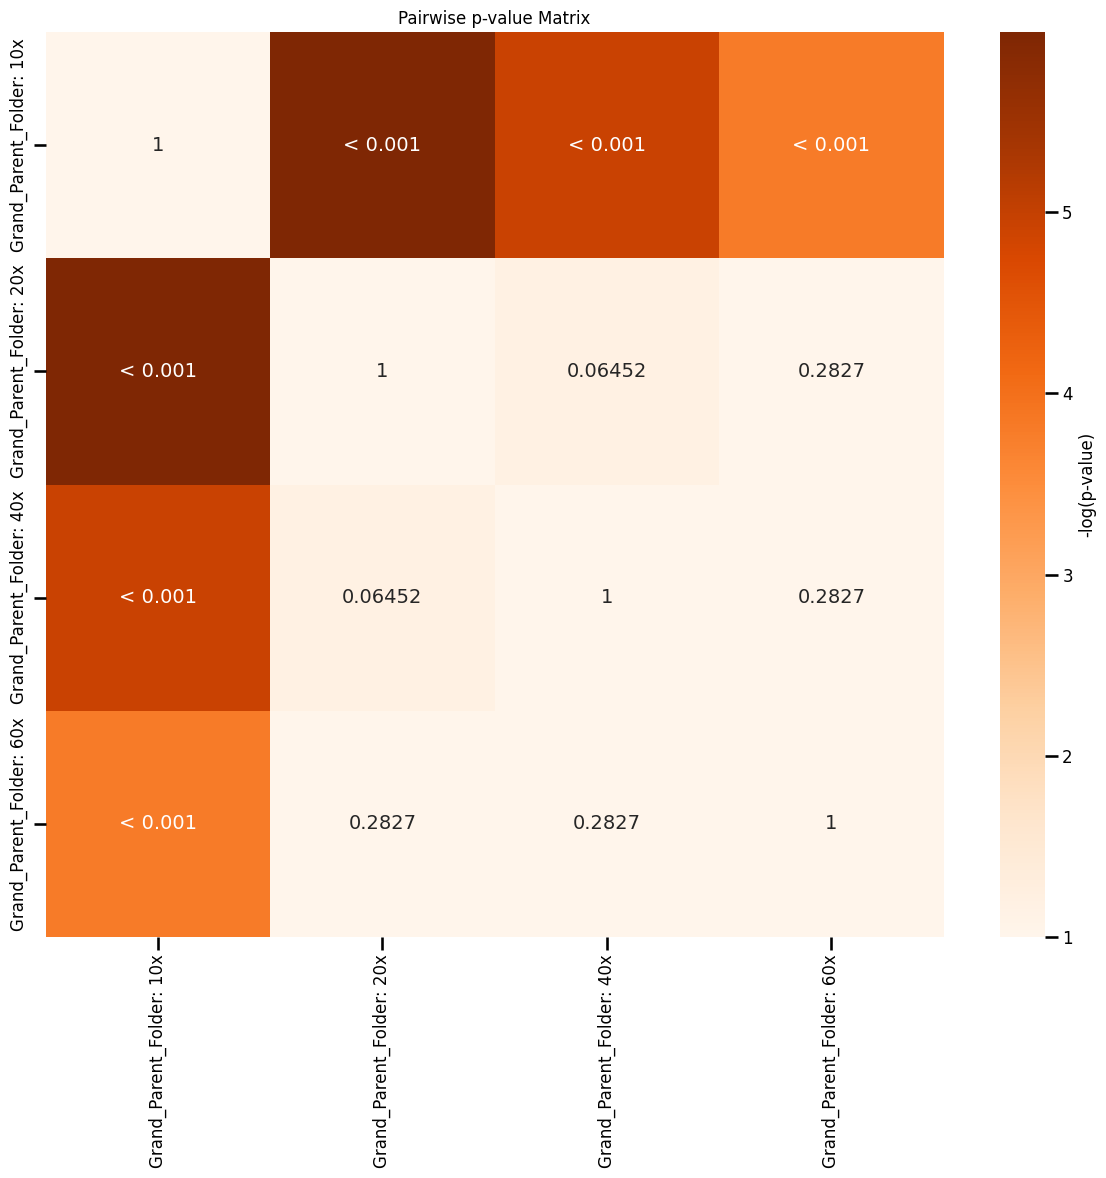

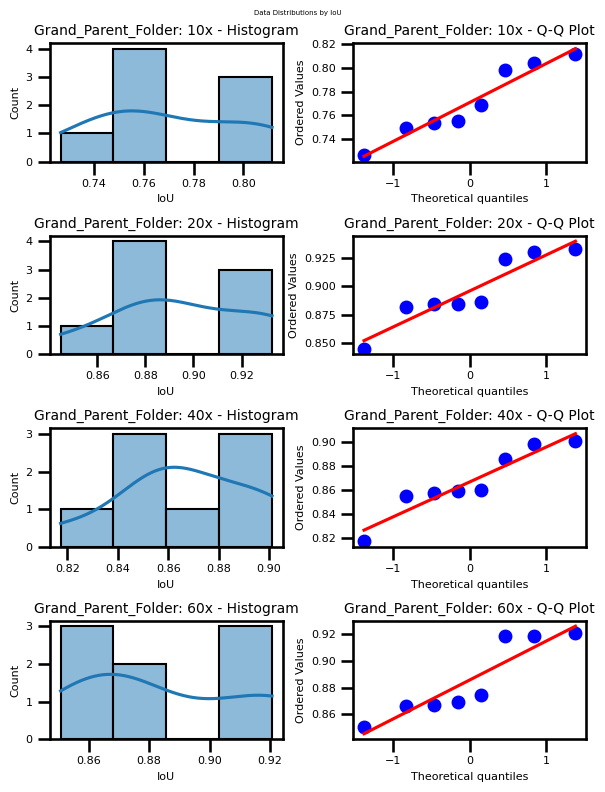

,Hierarchy1,Hierarchy2,Test,Statistic,p-value,Significance
0,Grand_Parent_Folder: 10x,Grand_Parent_Folder: 20x,t-test,-8.207161,0.000001,***
1,Grand_Parent_Folder: 10x,Grand_Parent_Folder: 40x,t-test,-6.600535,0.000012,***
2,Grand_Parent_Folder: 10x,Grand_Parent_Folder: 60x,Kolmogorov-Smirnov,1.000000,0.000155,***
3,Grand_Parent_Folder: 20x,Grand_Parent_Folder: 40x,t-test,2.006514,0.064517,
4,Grand_Parent_Folder: 20x,Grand_Parent_Folder: 60x,Kolmogorov-Smirnov,0.500000,0.282673,
5,Grand_Parent_Folder: 40x,Grand_Parent_Folder: 60x,Kolmogorov-Smirnov,0.500000,0.282673,


In [6]:
## Input variables for stats
ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/aiobio"
DATASET = "nuclei_aiobio_20xdata_rescalemodels"

QUANTITATIVE_COLUMN = "IoU"
CATEGORICAL_COLUMN = ["Grand_Parent_Folder"]
TEST_TYPE = "Kolmogorov-Smirnov" # "t-test"
TEST_CHOICE = "Automatic" # "Manual" 
FILENAME = "summary_stats.csv"
# import pandas as pd
# df = pd.read_csv(ANALYSIS_DIR)
# ## Compute basic stats
# print(df.groupby(CATEGORICAL_COLUMN)[QUANTITATIVE_COLUMN].describe())

## Compute statistical tests
results = stats.compute_statistical_analysis(ANALYSIS_DIR,
                                             DATASET,
                                             QUANTITATIVE_COLUMN,
                                             CATEGORICAL_COLUMN,
                                             filename = FILENAME,
                                             test_type=TEST_TYPE,
                                             choose_test=TEST_CHOICE)

plot_data_distributions(ANALYSIS_DIR,
                        DATASET,
                        QUANTITATIVE_COLUMN,
                        CATEGORICAL_COLUMN,
                        filename = FILENAME)
results

# 5. Compare results of different experiments for the same data acquisition.

### 5.1 Plot results

DONE!
DONE!
DONE!


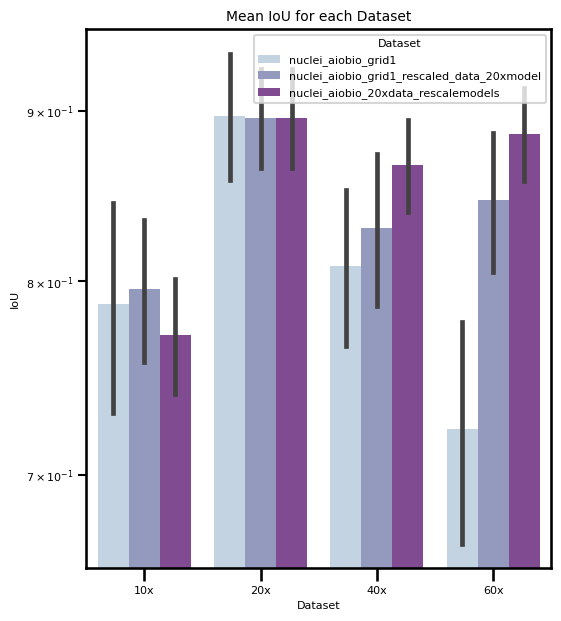

In [3]:
full_data = []
for DATASET in ["nuclei_aiobio_20xdata_rescalemodels", "nuclei_aiobio_grid1", "nuclei_aiobio_grid1_rescaled_data_20xmodel"]:
    ANALYSIS_DIR = "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/aiobio"
    OUTPUT_DIR = os.path.join(ANALYSIS_DIR, DATASET, "Results", "plots")
    
    # Get the csv files
    csv_dict = get_csv_dict(ANALYSIS_DIR)
    # Import CSVs
    path_instance_summary = [f for f in csv_dict[DATASET] if f.__contains__("summary_stats")][0]
    csv_instance_summary = pd.read_csv(path_instance_summary)
    csv_instance_summary["Dataset"] = DATASET
    if len(full_data) == 0:
        full_data = csv_instance_summary
    else:
        full_data = pd.concat([full_data, csv_instance_summary]).reset_index(drop=True)


y_axis = "IoU"
x_axis_order = ["10x", "20x", "40x", "60x"]
fig = plt.figure(figsize=(6, 7))
sns.barplot(data=full_data, 
            x="Grand_Parent_Folder", 
            y=y_axis, 
            order=x_axis_order, 
            hue="Dataset", 
            errorbar="sd", 
            palette="BuPu", 
            hue_order=["nuclei_aiobio_grid1", "nuclei_aiobio_grid1_rescaled_data_20xmodel", "nuclei_aiobio_20xdata_rescalemodels"])
plt.xlabel("Dataset")
plt.ylabel(y_axis)
#plt.ylim(0, 1)  # Assuming IoU is between 0 and 1
plt.title(f"Mean {y_axis} for each Dataset")
#plt.tight_layout()
plt.yscale('log')  # Set y-axis to logarithmic scale
fig.savefig(os.path.join(OUTPUT_DIR, f"{DATASET}_mean_{y_axis}_bar_plot.pdf"))
plt.show()


## 5.2. Statistical analysis
Calculate basic data distribution values and compare distributions accross different rescaling factors.
These can be calculated with the example data as follows:
1. **DATASET**
    - One of the following ones:
        - `"Saureus_instance_segmentation", "Deepbacs_Instance_Segmentation", "Deepbacs_Semantic_Segmentation", "Saureus_instance_segmentation_pc190723", "Saureus_instance_segmentation", "Worm_Semantic_Segmentation"`
2. **ANALYSIS_DIR**
    - The absolute path to `"Examples/analysis_results"`
3. **QUNATITATIVE_COLUMN**
    - Typically `"IoU"`. However, one can choose to compare other metrics such as `"f1_score", "pred_diameter_median", "pred_area", "Sensitivity", "pred_Circularity", "Accuracy"`. 
4. **CATEGORICAL_COLUMNS**
    - List of column names dividing the data in groups for comparison. E.g., `["Dataset", "Grand_Parent_Folder"]`.
5. **TEST_TYPE**
    - `"t-test"`: When both groups are normally distributed and have equal variances.
    - `"Welch's t-test"`: When both groups are normally distributed and have unequal variances.
    - `"Kolmogorov-Smirnov"`: When at least one of the variables is not normally distributed. 
6. **TEST_CHOICE** 
  - `"Automatic"` if you want to run an automatic testing based on assessed properties of the data distribution. 
  - `"Manual"` to manually indicate what test to run.


The statistical test chosen is Kolmogorov-Smirnov


/Users/esti/mambaforge/envs/rescale4dl/lib/python3.12/site-packages/rescale4dl/stats.py:343: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


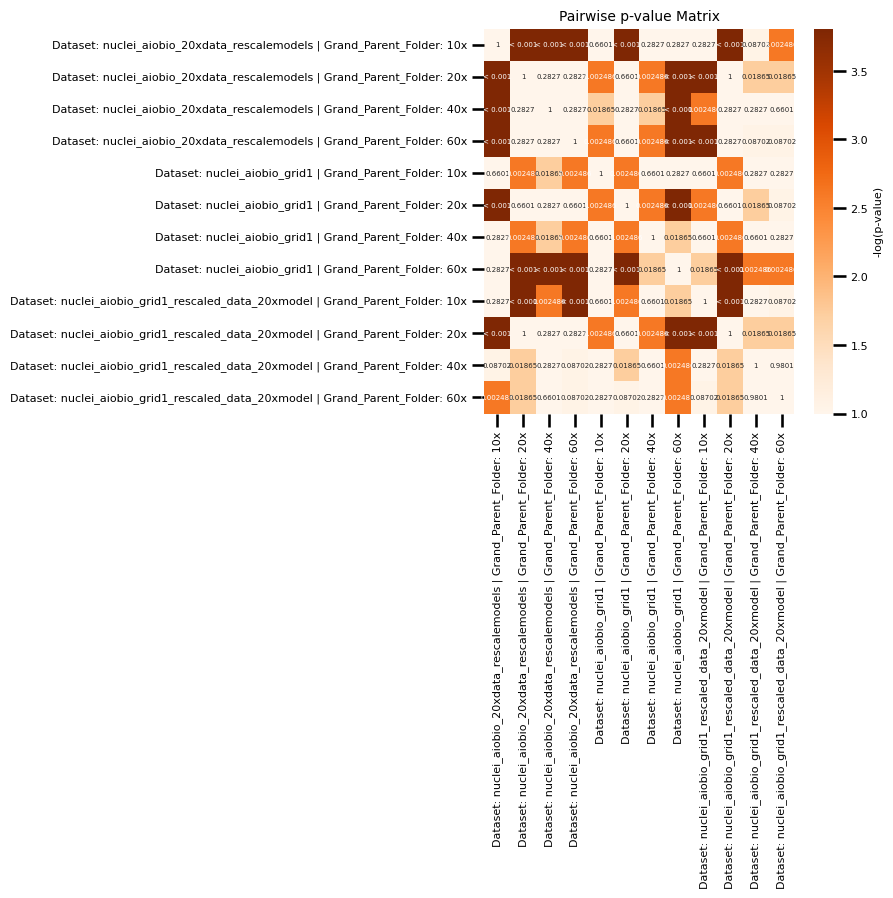

,Hierarchy1,Hierarchy2,Test,Statistic,p-value,Significance
0,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Kolmogorov-Smirnov,1.000,0.000155,***
1,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Kolmogorov-Smirnov,1.000,0.000155,***
2,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Kolmogorov-Smirnov,1.000,0.000155,***
3,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Dataset: nuclei_aiobio_grid1 | Grand_Parent_Fo...,Kolmogorov-Smirnov,0.375,0.660140,
4,Dataset: nuclei_aiobio_20xdata_rescalemodels |...,Dataset: nuclei_aiobio_grid1 | Grand_Parent_Fo...,Kolmogorov-Smirnov,1.000,0.000155,***
...,...,...,...,...,...,...
61,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Kolmogorov-Smirnov,0.500,0.282673,
62,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Kolmogorov-Smirnov,0.625,0.087024,
63,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Kolmogorov-Smirnov,0.750,0.018648,*
64,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Dataset: nuclei_aiobio_grid1_rescaled_data_20x...,Kolmogorov-Smirnov,0.750,0.018648,*


In [4]:
CATEGORICAL_COLUMNS = ["Dataset", "Grand_Parent_Folder"]
QUANTITATIVE_COLUMN = "IoU"
stats.compute_statistical_analysis_from_pandas(full_data,
                                               "/Users/esti/Documents/PROYECTOS/DOWNSAMPLING/EXPERIMENTS/aiobio/ALL/",
                                               QUANTITATIVE_COLUMN,
                                                CATEGORICAL_COLUMNS,
                                                test_type="Kolmogorov-Smirnov",
                                                choose_test="Manual")
